In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('14-income_evaluation.csv')


In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.shape


(32561, 15)

In [5]:
df.columns


Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

In [6]:
col_names = ["age","workclass","finalweight","education","education_num","marital_status","occupation","relationship","race","sex","capital_gain",
            "capital_loss","hours-per-week","native-country","income"]

df.columns = col_names



In [7]:
df.columns

Index(['age', 'workclass', 'finalweight', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   finalweight     32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [9]:
df.describe()

,age,finalweight,education_num,capital_gain,capital_loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
df.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [11]:
categorical = [col for col in df.columns if df[col].dtype == "O"]
numerical = [col for col in df.columns if df[col].dtype != "O"]

In [12]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'income']

In [13]:
numerical

['age',
 'finalweight',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours-per-week']

In [14]:
df[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native-country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [15]:
for col in categorical:
 
    print(df[col].value_counts())
    print("*******************")

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
*******************
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
*******************
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
*******************
occupation
Prof-specialt

In [16]:
df.income.value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

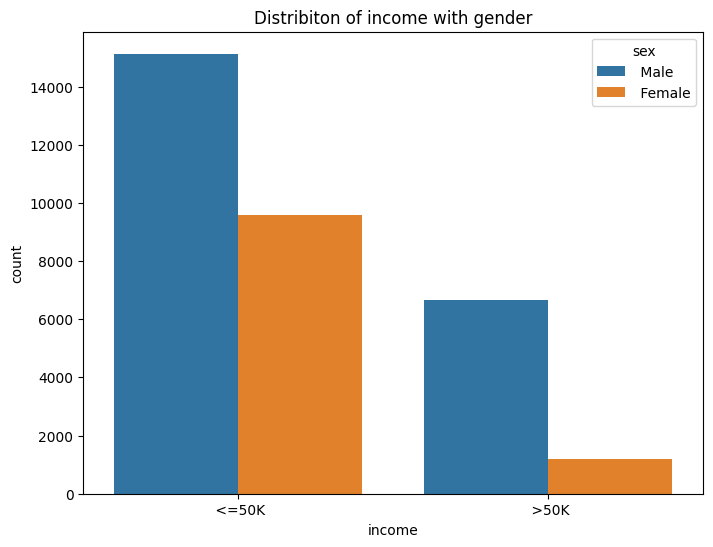

In [17]:
fig, ax = plt.subplots(figsize = (8,6))
ax = sns.countplot(x = "income" ,hue = "sex" ,data = df)
ax.set_title("Distribiton of income with gender")
plt.show()

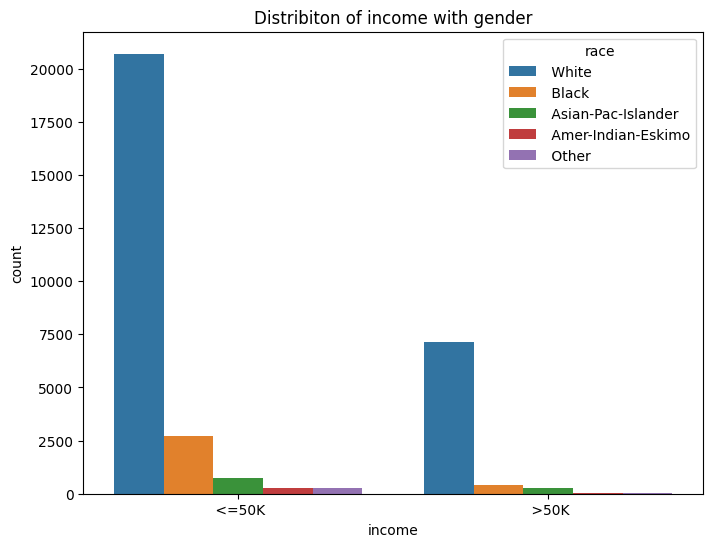

In [18]:
fig, ax = plt.subplots(figsize = (8,6))
ax = sns.countplot(x = "income" ,hue = "race" ,data = df)
ax.set_title("Distribiton of income with gender")
plt.show()

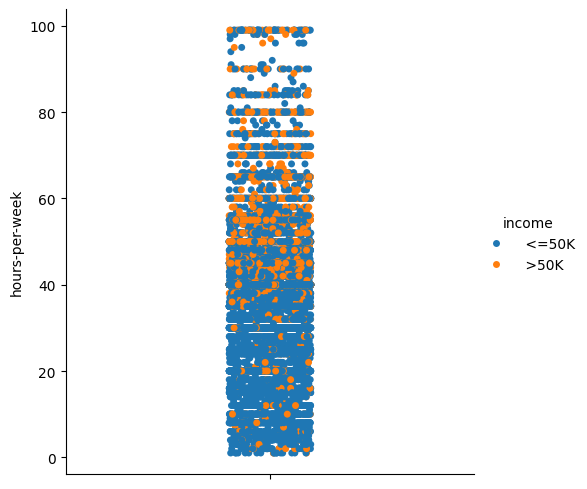

In [19]:
sns.catplot(y = df['hours-per-week'],hue = df['income'])
plt.show()

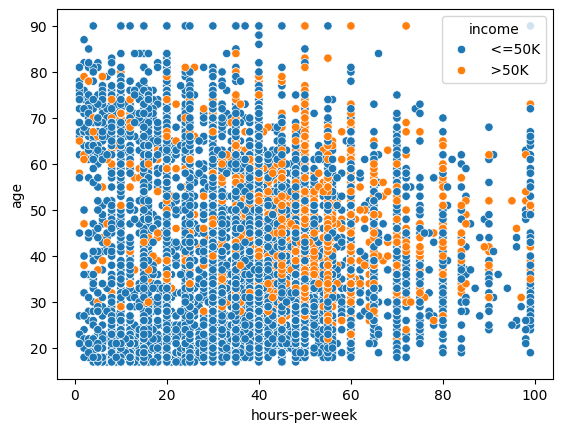

In [20]:
sns.scatterplot(x = df['hours-per-week'],y = df['age'],hue = df['income'])
plt.show()

In [21]:
over_40_hours = df[df["hours-per-week"]>40]
under_40_hours = df[df["hours-per-week"]<=40]

In [22]:
over_40_hours['income'].value_counts()

income
<=50K    5725
>50K     3856
Name: count, dtype: int64

In [23]:
under_40_hours['income'].value_counts()

income
<=50K    18995
>50K      3985
Name: count, dtype: int64

In [24]:
3856/(3856+5725)

0.4024632084333577

In [25]:
3985/(3985+18995)

0.17341166231505656

In [26]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'income']

In [27]:
df["workclass"].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [28]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [29]:
df["workclass"] = df["workclass"].replace(' ?',np.nan)

In [30]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [31]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [32]:
df["occupation"] = df["occupation"].replace(" ?",np.nan)

In [33]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [34]:
df["native-country"].value_counts()

native-country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [35]:
df["native-country"] = df["native-country"].replace(' ?',np.nan)


In [36]:
df["native-country"].value_counts()

native-country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France                           29
Greece       

In [37]:
df.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

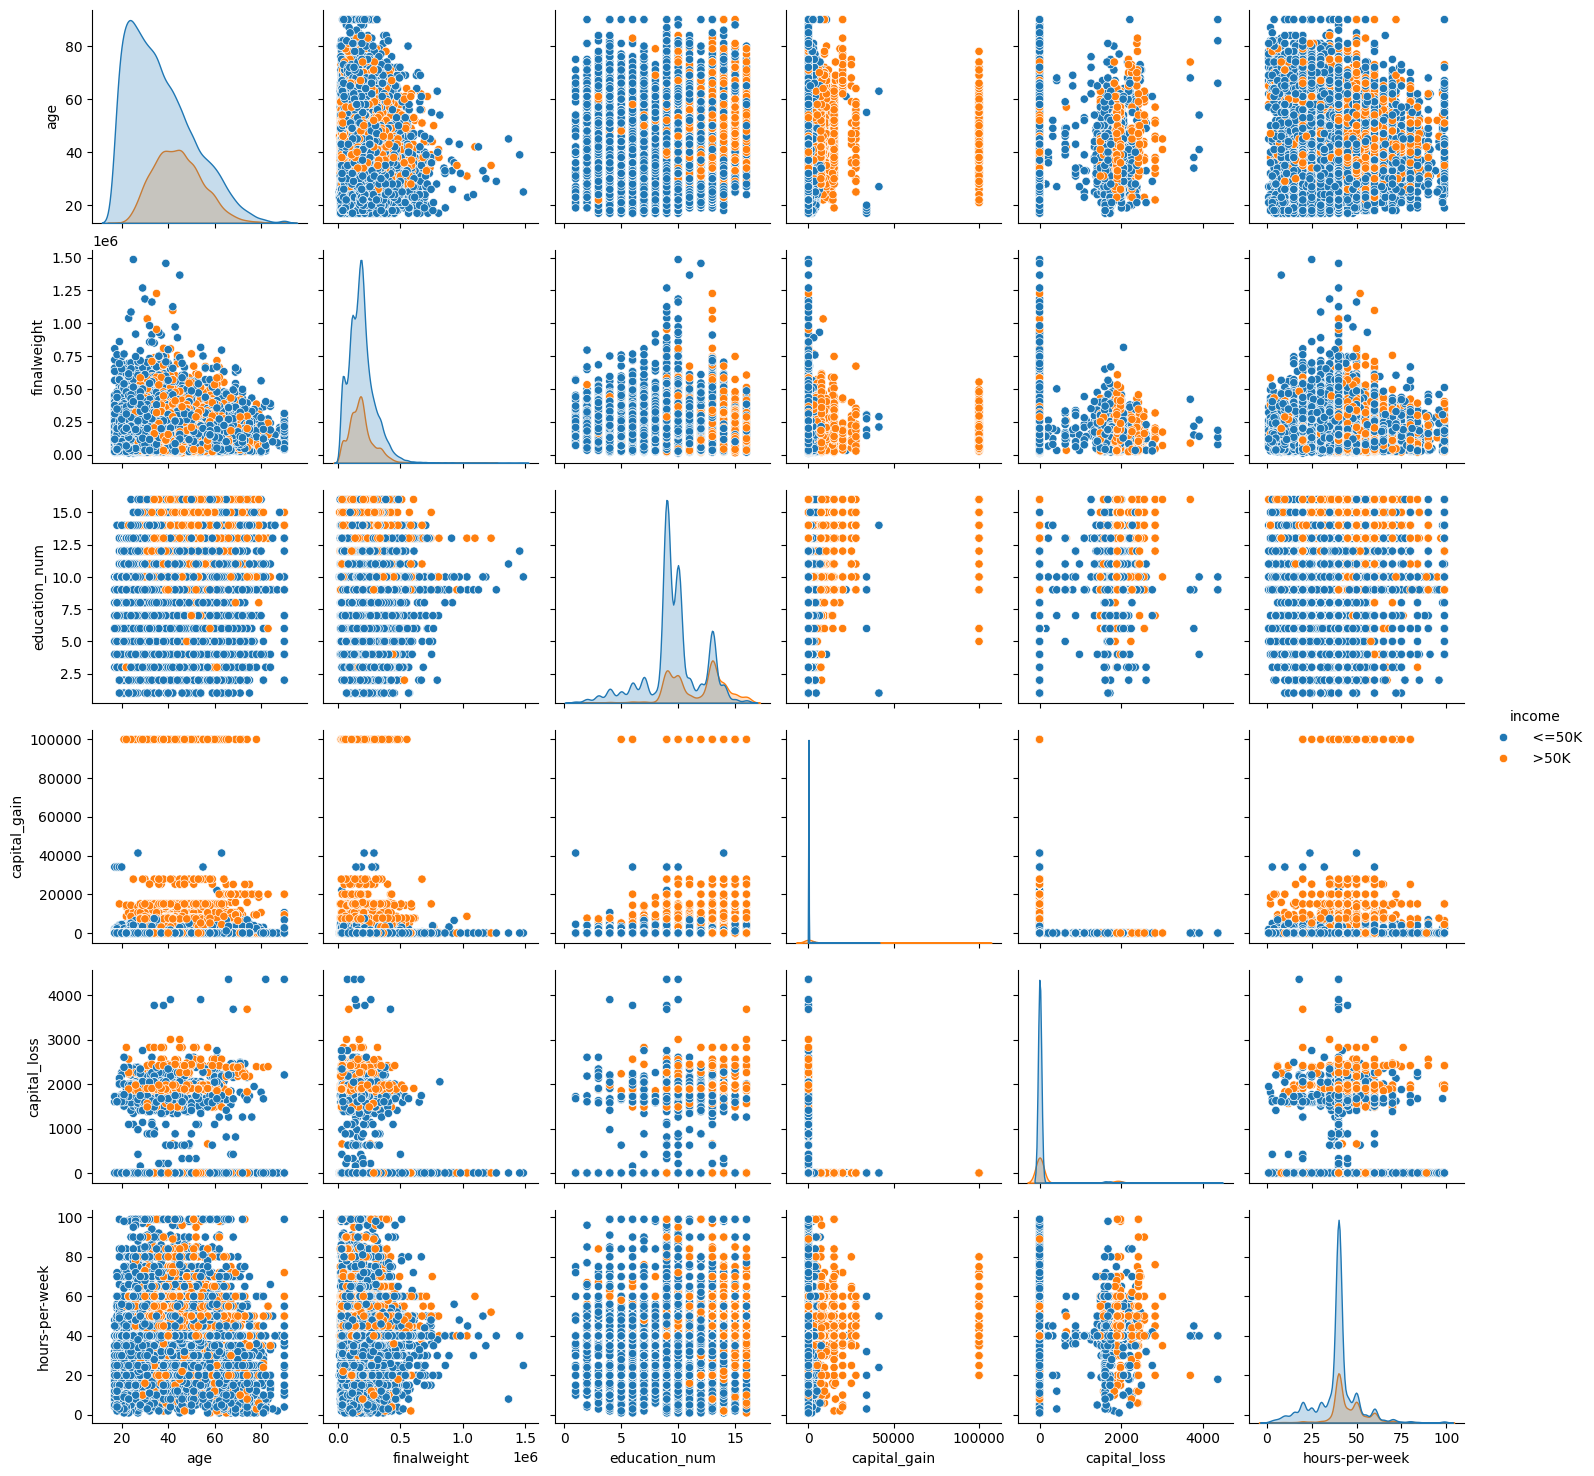

In [38]:
sns.pairplot(df,hue = 'income')
plt.show()

In [39]:
X = df.drop('income', axis = 1)
y = df['income']

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [42]:
categorical = [col for col in X_train.columns if X_train[col].dtype == "O"]

In [43]:
X_train[categorical].isnull().sum()

workclass         1276
education            0
marital_status       0
occupation        1278
relationship         0
race                 0
sex                  0
native-country     414
dtype: int64

In [44]:
X_test[categorical].isnull().sum()

workclass         560
education           0
marital_status      0
occupation        565
relationship        0
race                0
sex                 0
native-country    169
dtype: int64

In [45]:
X_train['workclass'].mode()[0]

' Private'

In [46]:
for i in [X_train , X_test]:
    i['workclass'] = i['workclass'].fillna(X_train['workclass'].mode()[0])
    i['occupation'] = i['occupation'].fillna(X_train['occupation'].mode()[0])
    i['native-country'] = i['native-country'].fillna(X_train['native-country'].mode()[0])

In [47]:
X_train[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native-country    0
dtype: int64

In [48]:
X_test[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native-country    0
dtype: int64

In [49]:
df[categorical].nunique() 

workclass          8
education         16
marital_status     7
occupation        14
relationship       6
race               5
sex                2
native-country    41
dtype: int64

In [50]:
y_train_binary = y_train.apply(lambda x:1 if x.strip() == '>50K' else 0)

In [51]:
y_train_binary

32098    1
25206    0
23491    1
12367    0
7054     0
        ..
13123    1
19648    0
9845     0
10799    1
2732     0
Name: income, Length: 22792, dtype: int64

In [52]:
target_means = y_train_binary.groupby(X_train['native-country']).mean()
target_means

native-country
Cambodia                      0.333333
Canada                        0.309524
China                         0.241379
Columbia                      0.021739
Cuba                          0.257143
Dominican-Republic            0.021277
Ecuador                       0.166667
El-Salvador                   0.101449
England                       0.295082
France                        0.300000
Germany                       0.284091
Greece                        0.263158
Guatemala                     0.041667
Haiti                         0.093750
Holand-Netherlands            0.000000
Honduras                      0.100000
Hong                          0.272727
Hungary                       0.111111
India                         0.391304
Iran                          0.366667
Ireland                       0.187500
Italy                         0.354167
Jamaica                       0.090909
Japan                         0.395349
Laos                          0.200000
Mexico    

In [53]:
X_train['native_country_encoded'] = X_train['native-country'].map(target_means)
X_train['native_country_encoded'] = X_train['native_country_encoded'].fillna(y_train_binary.mean())

X_test['native_country_encoded'] = X_test['native-country'].map(target_means)
X_test['native_country_encoded'] = X_test['native_country_encoded'].fillna(y_train_binary.mean())

In [54]:
X_test.head()

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours-per-week,native-country,native_country_encoded
22278,27,Private,177119,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,44,United-States,0.245722
8950,27,Private,216481,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,0.245722
7838,25,Private,256263,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,0.245722
16505,46,Private,147640,5th-6th,3,Married-civ-spouse,Transport-moving,Husband,Amer-Indian-Eskimo,Male,0,1902,40,United-States,0.245722
19140,45,Private,172822,11th,7,Divorced,Transport-moving,Not-in-family,White,Male,0,2824,76,United-States,0.245722


In [55]:
X_train = X_train.drop('native-country',axis =1)
X_test = X_test.drop('native-country',axis =1)

In [56]:
one_hot_catgories = ["workclass","education",
                     "marital_status","occupation","relationship","race","sex"
                     
                     ]

In [57]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [58]:
encoder = ColumnTransformer(
    transformers=[('cat',OneHotEncoder (handle_unknown="ignore",sparse_output=False) ,one_hot_catgories) #sparse_output=False bu matris yol numpy array qalsin demekdir
                 ],
    remainder='passthrough'
)

In [59]:
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

In [60]:
X_train_enc

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        60.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        38.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        50.        ,  0.24572168],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24572168],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        45.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        48.        ,  0.24572168]], shape=(22792, 65))

In [61]:
columns = encoder.get_feature_names_out()
columns

array(['cat__workclass_ Federal-gov', 'cat__workclass_ Local-gov',
       'cat__workclass_ Never-worked', 'cat__workclass_ Private',
       'cat__workclass_ Self-emp-inc', 'cat__workclass_ Self-emp-not-inc',
       'cat__workclass_ State-gov', 'cat__workclass_ Without-pay',
       'cat__education_ 10th', 'cat__education_ 11th',
       'cat__education_ 12th', 'cat__education_ 1st-4th',
       'cat__education_ 5th-6th', 'cat__education_ 7th-8th',
       'cat__education_ 9th', 'cat__education_ Assoc-acdm',
       'cat__education_ Assoc-voc', 'cat__education_ Bachelors',
       'cat__education_ Doctorate', 'cat__education_ HS-grad',
       'cat__education_ Masters', 'cat__education_ Preschool',
       'cat__education_ Prof-school', 'cat__education_ Some-college',
       'cat__marital_status_ Divorced',
       'cat__marital_status_ Married-AF-spouse',
       'cat__marital_status_ Married-civ-spouse',
       'cat__marital_status_ Married-spouse-absent',
       'cat__marital_status_ Never-mar

In [62]:
X_train = pd.DataFrame(X_train_enc, columns = columns, index = X_train.index)
X_test = pd.DataFrame(X_test_enc, columns = columns, index = X_test.index)

In [63]:
X_train

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours-per-week,remainder__native_country_encoded
32098,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,45.0,170871.0,9.0,7298.0,0.0,60.0,0.245722
25206,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,47.0,108890.0,9.0,1831.0,0.0,38.0,0.245722
23491,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,48.0,187505.0,10.0,0.0,0.0,50.0,0.245722
12367,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,29.0,145592.0,9.0,0.0,0.0,40.0,0.041667
7054,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,23.0,203003.0,4.0,0.0,0.0,25.0,0.284091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13123,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,43.0,33331.0,14.0,0.0,0.0,40.0,0.245722
19648,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,44.0,98466.0,6.0,0.0,0.0,35.0,0.245722
9845,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,23.0,45317.0,10.0,0.0,0.0,40.0,0.245722
10799,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,45.0,215862.0,16.0,7688.0,0.0,45.0,0.245722


In [64]:
cols = X_train.columns

In [65]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

In [66]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [67]:
X_train = pd.DataFrame(X_train,columns=cols)
X_test = pd.DataFrame(X_test,columns=cols)


In [69]:
#traning

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [72]:
rfc = RandomForestClassifier(n_estimators=10,random_state=15)
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=15)

In [73]:
y_pred = rfc.predict(X_test)

In [74]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [75]:
print('Accuracy:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))



Accuracy: 0.8470672535571706
[[6886  521]
 [ 973 1389]]
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7407
        >50K       0.73      0.59      0.65      2362

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769



In [76]:
rfc = RandomForestClassifier(n_estimators=100,random_state=15)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))



Accuracy: 0.8537209540382844
[[6870  537]
 [ 892 1470]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.73      0.62      0.67      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [77]:
rfc.feature_importances_

array([5.89915888e-03, 5.82375187e-03, 7.14292998e-06, 1.12395409e-02,
       5.45950100e-03, 9.14446600e-03, 4.95867851e-03, 7.49970941e-05,
       1.26676685e-03, 1.78936666e-03, 8.44081442e-04, 2.49805089e-04,
       3.53321264e-04, 1.49032443e-03, 1.07900514e-03, 2.45097237e-03,
       3.15104569e-03, 1.08197880e-02, 2.65277844e-03, 6.84630198e-03,
       7.92194647e-03, 2.85857892e-05, 4.02750221e-03, 5.92388104e-03,
       6.13768337e-03, 2.84733479e-04, 6.17521057e-02, 9.80661116e-04,
       2.54875412e-02, 1.67947319e-03, 1.71908968e-03, 5.54312037e-03,
       2.27790711e-05, 8.36620649e-03, 1.89641500e-02, 3.77276733e-03,
       3.09264886e-03, 4.42875165e-03, 7.56797784e-03, 9.70846089e-05,
       1.37068011e-02, 3.06774138e-03, 7.40362575e-03, 5.15548967e-03,
       5.31269539e-03, 4.44090385e-02, 9.48837044e-03, 1.44590705e-03,
       9.48597008e-03, 4.50150645e-03, 1.01949978e-02, 1.37613012e-03,
       3.39643432e-03, 4.90775153e-03, 8.37231704e-04, 7.03575103e-03,
      

In [81]:
feature_scores = pd.Series(rfc.feature_importances_,index=X_train.columns).sort_values(ascending = False)

In [95]:
feature_scores.tail(10)

cat__education_ 12th                      0.000844
cat__race_ Other                          0.000837
cat__education_ 5th-6th                   0.000353
cat__marital_status_ Married-AF-spouse    0.000285
cat__education_ 1st-4th                   0.000250
cat__occupation_ Priv-house-serv          0.000097
cat__workclass_ Without-pay               0.000075
cat__education_ Preschool                 0.000029
cat__occupation_ Armed-Forces             0.000023
cat__workclass_ Never-worked              0.000007
dtype: float64

In [97]:
X_train = X_train.drop(["cat__education_ 12th","cat__race_ Other","cat__education_ 5th-6th",
                        "cat__marital_status_ Married-AF-spouse","cat__education_ 1st-4th",
                     "cat__occupation_ Priv-house-serv", "cat__workclass_ Without-pay",
                        "cat__education_ Preschool","cat__occupation_ Armed-Forces","cat__workclass_ Never-worked" ],axis=1)

In [98]:
X_test = X_test.drop(["cat__education_ 12th","cat__race_ Other","cat__education_ 5th-6th",
                        "cat__marital_status_ Married-AF-spouse","cat__education_ 1st-4th",
                     "cat__occupation_ Priv-house-serv", "cat__workclass_ Without-pay",
                        "cat__education_ Preschool","cat__occupation_ Armed-Forces","cat__workclass_ Never-worked" ],axis=1)

In [99]:
rfc = RandomForestClassifier(n_estimators=100,random_state=15)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))



Accuracy: 0.853618589415498
[[6864  543]
 [ 887 1475]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.73      0.62      0.67      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [100]:
#hyper parametr tuning

In [104]:
rf_params = {
    "n_estimators": [100,200,500,1000],
    "max_depth" :[5,8,15,10,None],
    "max_features":["sqrt","log2",5,6,7,8],
    "min_samples_split":[2,8,15,20]
    
}

In [101]:
from sklearn.model_selection import RandomizedSearchCV

In [102]:
rfc = RandomForestClassifier()

In [105]:
rscv = RandomizedSearchCV(estimator=rfc,param_distributions=rf_params,cv=3,n_jobs=-1)
rscv.fit(X_train,y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 8, 15, 10, None],
                                        'max_features': ['sqrt', 'log2', 5, 6,
                                                         7, 8],
                                        'min_samples_split': [2, 8, 15, 20],
                                        'n_estimators': [100, 200, 500, 1000]})

In [106]:
y_pred = rscv.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.8631384993346299
[[6945  462]
 [ 875 1487]]
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7407
        >50K       0.76      0.63      0.69      2362

    accuracy                           0.86      9769
   macro avg       0.83      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [107]:
rscv.best_params_

{'n_estimators': 1000,
 'min_samples_split': 20,
 'max_features': 7,
 'max_depth': None}